In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [14]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── CONFIG ──────────────────────────────────────────────────────────────────
VOCAB_SIZE    = 10000
MAX_LENGTH    = 200
EMBEDDING_DIM = 128
BATCH_SIZE    = 64
EPOCHS        = 20
FILTER_SIZES  = [2, 3, 4, 5]
NUM_FILTERS   = 128
DROPOUT_RATE  = 0.5
DATA_PATH     = '/kaggle/input/datasets/cjpuertollano/clean-withrating/CLEANED(with Rating)_dataset.csv'


In [15]:
# ── 1. LOAD DATA ─────────────────────────────────────────────────────────────
try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    print("File not found — using synthetic demo data.")
    df = pd.DataFrame({
        'Review': [f"Sample review text number {i}" for i in range(5000)],
        'Label':  np.random.choice(['Original_Review', 'Computer_Generated'], 5000)
    })

texts  = df['Review'].astype(str).values
labels = df['Label'].values
print(f"Loaded {len(df)} samples | Classes: {pd.Series(labels).value_counts().to_dict()}")


Loaded 40411 samples | Classes: {'OR': 20215, 'CG': 20196}


In [16]:
# ── 2. TOKENIZATION ──────────────────────────────────────────────────────────
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
print(f"Vocab size: {len(tokenizer.word_index)} | Padded shape: {X.shape}")


Vocab size: 48455 | Padded shape: (40411, 200)


In [17]:
# ── 3. LABEL ENCODING ────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(labels)
print(f"Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Classes: {'CG': np.int64(0), 'OR': np.int64(1)}


In [18]:
# ── 4. TRAIN / VAL / TEST SPLIT ──────────────────────────────────────────────
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
X_val,   X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
print(f"Split → Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


Split → Train: 32328 | Val: 4041 | Test: 4042


In [19]:
# ── 5. MULTI-CHANNEL CNN MODEL ───────────────────────────────────────────────
#
#  Pipeline:
#  Input
#    ├─ Channel 1: Static (frozen) Embedding → Conv1D × filter_sizes → GlobalMaxPool
#    └─ Channel 2: Trainable Embedding       → Conv1D × filter_sizes → GlobalMaxPool
#  Concatenate all pooled outputs
#  Dense(256) → Dense(128) → Sigmoid output
#
def build_multichannel_cnn():
    inp = layers.Input(shape=(MAX_LENGTH,), name="input")

    # ── Channel 1: Static / Frozen Embedding ─────────────────────────────────
    # Simulates a pretrained embedding (weights frozen during training)
    static_emb = layers.Embedding(
        VOCAB_SIZE, EMBEDDING_DIM,
        trainable=False,                   # <── frozen
        name="static_embedding"
    )(inp)
    static_emb = layers.SpatialDropout1D(0.2)(static_emb)

    # ── Channel 2: Trainable Embedding ───────────────────────────────────────
    trainable_emb = layers.Embedding(
        VOCAB_SIZE, EMBEDDING_DIM,
        trainable=True,                    # <── fine-tuned
        name="trainable_embedding"
    )(inp)
    trainable_emb = layers.SpatialDropout1D(0.2)(trainable_emb)

    # ── Parallel Conv1D layers per channel ───────────────────────────────────
    pooled = []
    for emb, tag in [(static_emb, "static"), (trainable_emb, "trainable")]:
        for fs in FILTER_SIZES:
            x = layers.Conv1D(NUM_FILTERS, fs, activation='relu',
                              padding='same', name=f"conv_{tag}_fs{fs}")(emb)
            x = layers.BatchNormalization()(x)
            x = layers.GlobalMaxPooling1D(name=f"pool_{tag}_fs{fs}")(x)
            pooled.append(x)

    # ── Concatenate all outputs ───────────────────────────────────────────────
    merged = layers.concatenate(pooled, name="concat")   # shape: (batch, 2 × 4 × NUM_FILTERS)

    # ── Dense → Output ────────────────────────────────────────────────────────
    x = layers.Dense(256, activation='relu')(merged)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid', name="output")(x)

    return models.Model(inputs=inp, outputs=out)

model = build_multichannel_cnn()
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 200)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_embedding    │ (None, 200, 128)  │  1,280,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trainable_embedding │ (None, 200, 128)  │  1,280,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 200, 128)  │          0 │ static_embedding… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_3 │ (None, 200, 128)  │          0 │ trainable_embedd… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_static_fs2     │ (None, 200, 128)  │     32,896 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_static_fs3     │ (None, 200, 128)  │     49,280 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_static_fs4     │ (None, 200, 128)  │     65,664 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_static_fs5     │ (None, 200, 128)  │     82,048 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_trainable_fs2  │ (None, 200, 128)  │     32,896 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_trainable_fs3  │ (None, 200, 128)  │     49,280 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_trainable_fs4  │ (None, 200, 128)  │     65,664 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_trainable_fs5  │ (None, 200, 128)  │     82,048 │ spatial_dropout1… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 128)  │        512 │ conv_static_fs2[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 128)  │        512 │ conv_static_fs3[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 128)  │        512 │ conv_static_fs4[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 128)  │        512 │ conv_static_fs5[… │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 3,320,833 (12.67 MB)

 Trainable params: 2,038,017 (7.77 MB)

 Non-trainable params: 1,282,816 (4.89 MB)

In [20]:
# ── 6. CALLBACKS ─────────────────────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
]


In [21]:
# ── 7. TRAIN ─────────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6596 - loss: 0.6932 - precision: 0.6552 - recall: 0.6553

506/506 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.6597 - loss: 0.6929 - precision: 0.6553 - recall: 0.6554 - val_accuracy: 0.6256 - val_loss: 0.5682 - val_precision: 0.9885 - val_recall: 0.2543 - learning_rate: 1.0000e-04
Epoch 2/20
505/506 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8463 - loss: 0.3469 - precision: 0.8410 - recall: 0.8491

506/506 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8464 - loss: 0.3468 - precision: 0.8410 - recall: 0.8491 - val_accuracy: 0.8953 - val_loss: 0.2396 - val_precision: 0.9357 - val_recall: 0.8491 - learning_rate: 1.0000e-04
Epoch 3/20
505/506 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8871 - loss: 0.2670 - precision: 0.8818 - recall: 0.8905

506/506 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8871 - loss: 0.2669 - precision: 0.8818 - recall: 0.8905 - val_accuracy: 0.9065 - val_loss: 0.2107 - val_precision: 0.9496 - val_recall: 0.8585 - learning_rate: 1.0000e-04
Epoch 4/20
505/506 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9173 - loss: 0.2005 - precision: 0.9119 - recall: 0.9215

506/506 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9173 - loss: 0.2005 - precision: 0.9119 - recall: 0.9215 - val_accuracy: 0.9213 - val_loss: 0.1819 - val_precision: 0.9561 - val_recall: 0.8832 - learning_rate: 1.0000e-04
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9347 - loss: 0.1606 - precision: 0.9287 - recall: 0.9398 - val_accuracy: 0.9173 - val_loss: 0.1847 - val_precision: 0.9632 - val_recall: 0.8679 - learning_rate: 1.0000e-04
Epoch 6/20
504/506 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9489 - loss: 0.1284 - precision: 0.9446 - recall: 0.9523
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
506/506 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9490 - loss: 0.1283 - precision: 0.9447 - recall: 0.9523 - val_accuracy: 0.9183 - val_loss: 0.1986 - val_precision: 0.9753 - val_recall: 0.8585 - learning_rate: 1.0000e-04
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9611 - loss: 0.0999 - precision: 0.95

In [22]:
# ── 8. EVALUATE ──────────────────────────────────────────────────────────────
test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)
f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec + 1e-7)

y_pred = (model.predict(X_test, verbose=0).flatten() > 0.5).astype(int)

print("\n── TEST RESULTS ──────────────────────────────────────────")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall   : {test_rec:.4f}")
print(f"  F1-Score : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


── TEST RESULTS ──────────────────────────────────────────
  Accuracy : 0.9228
  Precision: 0.9652
  Recall   : 0.8773
  F1-Score : 0.9192

Classification Report:
              precision    recall  f1-score   support

          CG       0.89      0.97      0.93      2020
          OR       0.97      0.88      0.92      2022

    accuracy                           0.92      4042
   macro avg       0.93      0.92      0.92      4042
weighted avg       0.93      0.92      0.92      4042



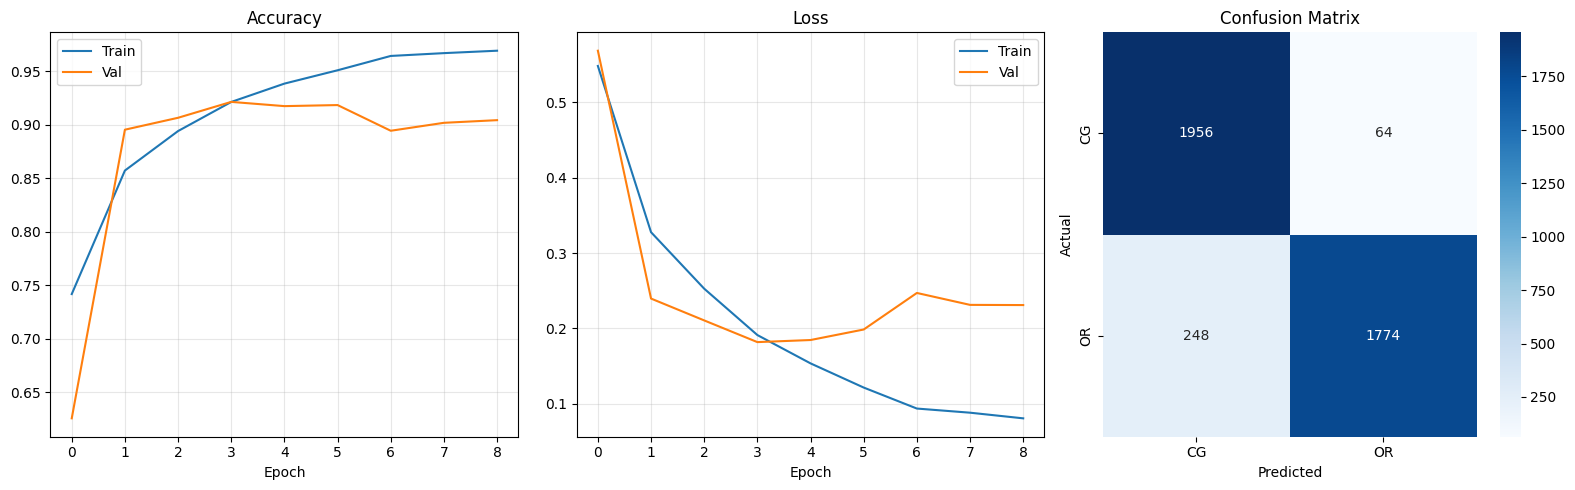

In [23]:
# ── 9. PLOTS ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy');  axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss');      axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── 10. INTERACTIVE INPUT ────────────────────────────────────────────────────
def predict_review(text):
    """
    Processes raw text and returns a structured prediction.
    """
    # 1. Preprocess: Tokenize and Pad
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
    
    # 2. Model Prediction
    # Note: le.transform(['Computer_Generated']) tells us if AI is 0 or 1
    # Usually, LabelEncoder sorts alphabetically: 
    # Computer_Generated = 0, Original_Review = 1
    pred_prob = model.predict(padded, verbose=0)[0][0]
    
    # 3. Interpret Result
    # We use the label encoder to ensure we map back to the right string
    # If prob > 0.5, it's the class represented by 1. Else 0.
    class_idx = 1 if pred_prob > 0.5 else 0
    label = le.inverse_transform([class_idx])[0]
    
    # Calculate confidence based on proximity to 1 or 0
    confidence = pred_prob if class_idx == 1 else (1 - pred_prob)
    
    if confidence > 0.90:
        level = "Very High"
    elif confidence > 0.75:
        level = "High"
    else:
        level = "Moderate"
        
    return {
        'label': label,
        'confidence': confidence,
        'level': level,
        'raw_score': pred_prob
    }

print("\n" + "="*60)
print("             🚀 AI vs. HUMAN REVIEW DETECTOR")
print("="*60)
print("Instructions: Enter a product review below to analyze its origin.")
print("Type 'quit' or 'exit' to stop.")

while True:
    print("\n" + "─"*60)
    user_input = input("📝 ENTER REVIEW: ").strip()
    
    if user_input.lower() in ['quit', 'exit']:
        print("👋 Goodbye!")
        break
    
    if len(user_input) < 5:
        print("⚠️ Review is too short for a reliable analysis.")
        continue

    # Get Prediction
    res = predict_review(user_input)
    
    # Color-coded style output (using simple ASCII)
    color_box = "■" * int(res['confidence'] * 20)
    gray_box = "□" * (20 - len(color_box))
    
    print(f"\nRESULT    : {res['label'].upper()}")
    print(f"CONFIDENCE: [{color_box}{gray_box}] {res['confidence']*100:.1f}% ({res['level']})")
    
    # If score is close to 0, it's Computer Generated
    if res['raw_score'] < 0.5:
        print("⚠️ Warning: This text shows patterns typical of AI generation.")
    else:
        print("✅  This review appears to be written by a human.")


             🚀 AI vs. HUMAN REVIEW DETECTOR
Instructions: Enter a product review below to analyze its origin.
Type 'quit' or 'exit' to stop.

────────────────────────────────────────────────────────────


📝 ENTER REVIEW:  The product is highly efficient and offers great value for the price. I am very satisfied with the overall quality and performance.



RESULT    : CG
CONFIDENCE: [■■■■■■■■■■■■□□□□□□□□] 64.9% (Moderate)
⚠️ Warning: This text shows patterns typical of AI generation.

────────────────────────────────────────────────────────────


📝 ENTER REVIEW:  This item arrived in excellent condition, the packaging was secure and the delivery was good. 



RESULT    : CG
CONFIDENCE: [■■■■■■■■■■■■■■■■□□□□] 83.4% (High)
⚠️ Warning: This text shows patterns typical of AI generation.

────────────────────────────────────────────────────────────


...


RESULT    : OR
CONFIDENCE: [■■■■■■■■■■■■■■■■■■□□] 90.6% (Very High)
✅  This review appears to be written by a human.

────────────────────────────────────────────────────────────


📝 ENTER REVIEW:  I GOTTA SAY, THIS WAS THE BEST PRODUCT I EVER BOUGHT. Very cheap yet useful.



RESULT    : OR
CONFIDENCE: [■■■■■■■■■■■□□□□□□□□□] 58.7% (Moderate)
✅  This review appears to be written by a human.

────────────────────────────────────────────────────────────


📝 ENTER REVIEW:  This is my purchase of the month. Thanks seller



RESULT    : OR
CONFIDENCE: [■■■■■■■■■■□□□□□□□□□□] 54.9% (Moderate)
✅  This review appears to be written by a human.

────────────────────────────────────────────────────────────
